# 张量网络（torch）

In [1]:
import quante as qt
import quante.torch_utils as qtc
import numpy as np
import torch as tc
from tqdm import tqdm
op = qt.generate.operas

## 第一部分 MPS

建立随机 mps

In [2]:
L = 12
𝜓 = qtc.MPS.from_random(L, bond_dim=4, dtype=tc.float64, device='cpu')
𝜓.show()

MPS;  torch.float64;  norm: 1.061e+05;  maxbonddim: 4;  device: cpu;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
         ----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻----
bonddim:  1     4     4     4     4     4     4     4     4     4     4     4     1
site:        0     1     2     3     4     5     6     7     8     9     10    11 


建立一些常用的 mps

In [4]:
qtc.MPS.from_ghz_state(L=3)  # |000> + |111>
qtc.MPS.from_w_state(L=3, which='up')  # |001> + |010> + |100>
qtc.MPS.from_w_state(L=3, which='down')  # |110> + |101> + |011>
qtc.MPS.from_vector(tc.randn(2**4, dtype=tc.complex128)) 
qtc.MPS.from_product_state(['up', 'down']*5)  # |1010101010>

MPS;  torch.float64;  norm: 1.000e+00;  maxbonddim: 1;  device: cpu;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
         ----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻----
bonddim:  1     1     1     1     1     1     1     1     1     1     1
site:        0     1     2     3     4     5     6     7     8     9  

移动正交中心

In [5]:
𝜓.orthogonalize_(0)
𝜓

MPS;  torch.float64;  norm: 3.072e+04;  maxbonddim: 4;  device: cpu;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
         ----◻-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁----
bonddim:  1     4     4     4     4     4     4     4     4     4     4     2     1
site:        0     1     2     3     4     5     6     7     8     9     10    11 

计算 norm，归一化

In [6]:
𝜓.norm()

tensor(30722.6914, dtype=torch.float64)

In [7]:
𝜓.normalize_()
𝜓.norm()

tensor(1., dtype=torch.float64)

计算纠缠熵

In [10]:
𝜓.entanglement_entropy(range(1,L))

[tensor(0.1727, dtype=torch.float64),
 tensor(0.6835, dtype=torch.float64),
 tensor(0.7574, dtype=torch.float64),
 tensor(0.9234, dtype=torch.float64),
 tensor(0.9356, dtype=torch.float64),
 tensor(0.9289, dtype=torch.float64),
 tensor(0.7147, dtype=torch.float64),
 tensor(0.9722, dtype=torch.float64),
 tensor(1.0512, dtype=torch.float64),
 tensor(0.7590, dtype=torch.float64),
 tensor(0.6386, dtype=torch.float64)]

计算局域观测量

In [33]:
𝜓.measure('x',0)
𝜓.measure('xx',0)
𝜓.measure(['x', 'x'],[0, 2])

tensor(0.1659, dtype=torch.float64)

In [62]:
𝜓.measure(op.heisenberg_operator(L))
L

10

In [36]:
𝜓.measure(np.random.randn(4,4), 0)

tensor(-0.0623, dtype=torch.float64)

In [37]:
𝜓.measure(qtc.MPO.from_random(L=2, bond_dim=2, dtype=tc.float64), 0)

tensor(-0.7623, dtype=torch.float64)

In [30]:
tmp = qtc.MPS.from_product_state(['up', 'down']*5)  # |1010101010>
[tmp.measure('Z',i).item() for i in range(10)]

[1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0, -1.0]

作用局域门

In [31]:
mat = tc.randn(4,4, dtype=tc.float64)
n𝜓 = 𝜓.copy()  # 复制原来的 𝜓
n𝜓.apply_gate_(0, mat)  # 在 (0,1) 位置作用一个 4x4 的矩阵

内积

In [32]:
show(𝜓.inner(n𝜓))  # < ψ | nψ >
𝜓.measure(mat, 0)  # 与内积结果相同

ψ.inner(nψ): tensor(0.0447, dtype=torch.float64)


tensor(0.0447, dtype=torch.float64)

tebd

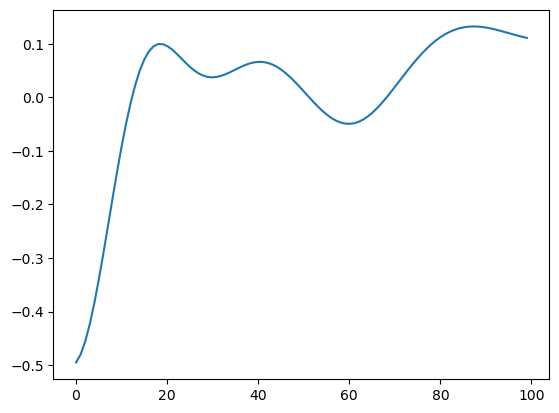

In [ ]:
ham = op.heisenberg_operator(L)
𝜓t = qtc.MPS.from_product_state(["up", "down"]*(L//2), dtype=tc.complex128)
gates = ham.trotter_gates(L, tau=0.1, pauli=False)
res = []
for i in range(100):
    for pos, gate in zip(*gates):
        𝜓t.apply_gate_(pos, gate)
    res.append(𝜓t.measure('z', 3).item().real)
import matplotlib.pyplot as plt
plt.plot(res)

## itebd

100%|##########| 500/500 [02:39<00:00,  3.14it/s] 


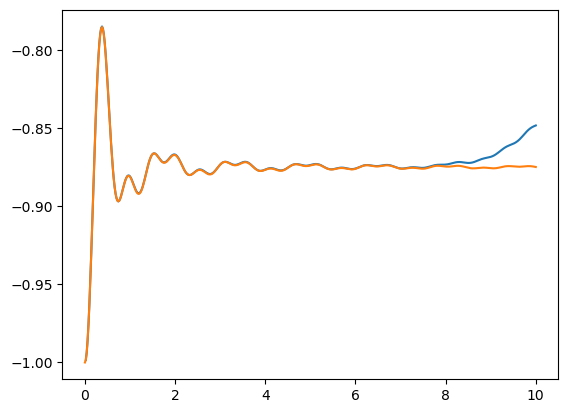

In [2]:
# 生成无穷长 MPS
tmp1 = tc.zeros(1,2,1, dtype=tc.complex128, device='cpu')
tmp1[0,1,0] = 1.
tmp2 = tc.zeros(1,2,1, dtype=tc.complex128, device='cpu')
tmp2[0,1,0] = 1.

psi = qtc.MPS([tmp1, tmp2], [tc.tensor(1., dtype=tc.float64, device='cpu'), tc.tensor(1., dtype=tc.float64, device='cpu')], L=tc.inf)

# 生成两体门
g = 2
ham = op.xx(0,1) + 0.5 * g * op.z(0) + 0.5 * g * op.z(1)
basis = qt.generate.basis.spin_basis(2)
mat = ham.to_matrix(basis, pauli=True)
t = 0.02  # 0.05 会有明显误差
expiH = tc.tensor(qt.linalg.expm(mat, -1j*t), dtype=tc.complex128, device='cpu').reshape(2,2,2,2)

# itebd 演化
ts = []
sz = []
bonds = []
cur_t = 0.
for i in tqdm(range(500), ascii=True):
    psi.apply_gate_(0, expiH, svd_alg='svd', trunc_para=(500,1e-8,None), unitary_gate=True)
    psi.apply_gate_(1, expiH, svd_alg='svd', trunc_para=(500,1e-8,None), unitary_gate=True)
    cur_t += t
    sz.append(psi.measure('Z', 0).real)
    ts.append(cur_t)
    bonds.append(psi.maxbonddim())
import matplotlib.pyplot as plt
plt.plot(ts, sz)

#############################
# 对比严格解
#############################
import scipy.integrate as spi
jx = 1
jy = 0
hz = 2
λ = (jx + jy)/2
γ = (jx - jy)/2
theta = lambda k: np.arctan2(2*γ*np.sin(k),  hz - 2*λ*np.cos(k))
omega = lambda k: 2 * np.sqrt((2*γ*np.sin(k))**2 + (hz - 2*λ*np.cos(k))**2)
ts = np.linspace(0, 10, 500)
sigma_zs = np.zeros_like(ts, dtype=np.float64)
for i, t in enumerate(ts):
    sigma_zs[i] = 1/np.pi * spi.quad(lambda k: np.sin(theta(k))**2 * np.sin(omega(k) * t)**2, -np.pi, np.pi)[0] - 1
plt.plot(ts, sigma_zs)

# 运行时间 2m 22.2s

## 第二部分 MPO

使用 automata 建立一个 mpo

In [3]:
ham = op.heisenberg_operator(L)
ℋ = ham.to_mpo(pauli=False, backend='torch', device='cpu')
ℋ

MPO;  torch.float64;  norm: 4.851e+15;  maxbonddim: 5;  device: cpu;
physdim:    2|    2|    ...   2|    2|    2| 
         ----◻-----◻--- ... ---◻-----◻-----◻----
physdim:    2|    2|    ...   2|    2|    2| 
bonddim:  1     4    5  ...  5    5     5     1
site:        0     1    ...    97    98    99 

也可以使用 quimb 建立 mpo

d:\Software\miniconda3\envs\py311\Lib\site-packages\cotengra\hyperoptimizers\hyper.py:33: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(


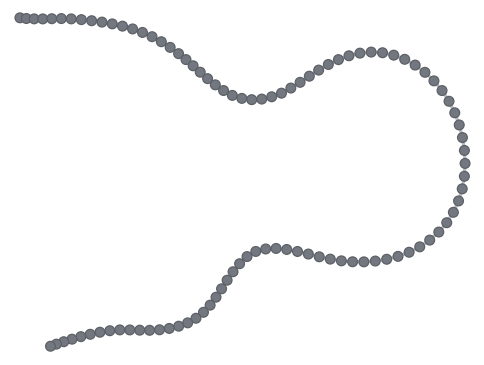

In [4]:
ham = op.heisenberg_operator(L)
quimbH = ham.to_mpo(pauli=False, backend='quimb', device='cpu')
quimbH.draw()

计算内积

In [5]:
L = 100
ham = op.heisenberg_operator(L) + op.y(0)
H = ham.to_mpo(pauli=False, backend='torch', device='cpu')
psi = qtc.MPS.from_random(L, bond_dim=4)

H.mele(psi, psi)  # <psi|H|psi>

tensor(6.4861e+88+1.0601e+73j, dtype=torch.complex128)

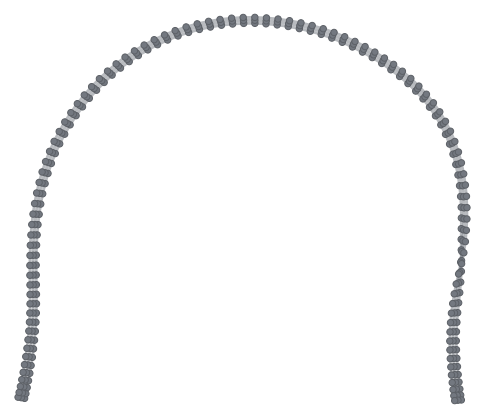

6.486096129105527e+88

In [6]:
import quimb.tensor as qtn
Hq = H.to_quimb()
psiq:qtn.MatrixProductState = psi.to_quimb()

dagpsiq = psiq.conj().reindex({f"k{i}":f"b{i}" for i in range(L)})
Hq = Hq.reindex({
    **{f"k{i}":f"b{i}" for i in range(L)},
    **{f"b{i}":f"k{i}" for i in range(L)}
    })
(dagpsiq | Hq | psiq).draw(show_tags=False)
(dagpsiq | Hq | psiq) ^ ...

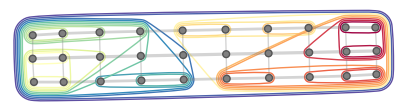

(<Figure size 500x500 with 1 Axes>, <Axes: >)

In [38]:
tree = (dagpsiq | Hq | psiq).contraction_tree()
tree.plot_rubberband()

In [41]:
vec = psi.to_vector()
mat = H.to_matrix()
vec.conj().T @ mat @ vec

C:\Users\hzhu\AppData\Local\Temp\ipykernel_19160\1257858387.py:3: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3687.)
  vec.conj().T @ mat @ vec


tensor(-28522201.8990-2.9104e-09j, dtype=torch.complex128)

In [20]:
psi.to_itensor()
H.to_itensor()
# inner(psi', Hs, psi) in itensor

## dmrg

dmrg 算基态

In [8]:
L = 10
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False, backend='torch', device='cpu')
eng, vec = H.dmrg(nsweep=10)
ham.gdenergy()

After sweep 0: energy=-4.257687779267926 maxchi=8 time=0.049
After sweep 1: energy=-4.258035206797452 maxchi=20 time=0.131
After sweep 2: energy=-4.258035206806072 maxchi=20 time=0.105


array([-4.25803521])

In [9]:
L = 100
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False, backend='torch', device='cpu')
eng, vec = H.dmrg(nsweep=10)

After sweep 0: energy=-44.04995973125143 maxchi=8 time=0.734
After sweep 1: energy=-44.1243710252655 maxchi=20 time=0.547
After sweep 2: energy=-44.12772892772186 maxchi=72 time=1.350
After sweep 3: energy=-44.12773984315916 maxchi=100 time=2.696
After sweep 4: energy=-44.12773985329792 maxchi=106 time=2.750


dmrg 算第一激发态

In [16]:
L = 10
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False, backend='torch', device='cpu')
eng, vec1 = ℋ.dmrg()
eng, vec2 = ℋ.dmrg(Ms=[vec1])
ham.gdenergy(k=2) # ed 结果

After sweep 0: energy=-4.257788698946593 maxchi=8 time=0.052
After sweep 1: energy=-4.258035206797263 maxchi=20 time=0.134
After sweep 2: energy=-4.258035206806074 maxchi=20 time=0.115
After sweep 0: energy=-3.9306267323682365 maxchi=10 time=0.109
After sweep 1: energy=-3.9306735456202575 maxchi=20 time=0.199
After sweep 2: energy=-3.9306735894356377 maxchi=37 time=0.169


array([-3.93067359, -4.25803521])

In [17]:
L = 100
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False, backend='torch', device='cpu')
eng, vec1 = ℋ.dmrg()
eng, vec2 = ℋ.dmrg(Ms=[vec1])

After sweep 0: energy=-44.014995809428385 maxchi=8 time=1.066
After sweep 1: energy=-44.121873800124796 maxchi=20 time=0.805
After sweep 2: energy=-44.12772184822584 maxchi=72 time=1.976
After sweep 3: energy=-44.12773984227919 maxchi=100 time=4.156
After sweep 4: energy=-44.12773985305069 maxchi=106 time=3.982
After sweep 0: energy=-43.94784734999093 maxchi=8 time=1.097
After sweep 1: energy=-44.08505229025197 maxchi=20 time=0.846
After sweep 2: energy=-44.08729075382143 maxchi=69 time=1.926
After sweep 3: energy=-44.08729913474456 maxchi=100 time=3.998
After sweep 4: energy=-44.0872991442976 maxchi=102 time=4.040


dmrg 算 MPO 求和的基态

In [21]:
L = 10
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False, backend='torch', device='cpu')
hams = [ham + op.sum(np.random.rand() * op.z(i) for i in range(L)) for _ in range(10)]
mpos = [h.to_mpo() for h in hams]
qtc.DMRG(mpos).run2()

op.sum(hams).gdenergy() # ed 的结果

After sweep 0: energy=-44.69091611103433 maxchi=8 time=0.103
After sweep 1: energy=-44.693552099665254 maxchi=16 time=0.190
After sweep 2: energy=-44.69355210177027 maxchi=16 time=0.135


array([-44.69355211])

准一维系统的基态
```
      0   2   4   6
   ---◻---◻---◻---◻---
      |   |   |   |
   ---◻---◻---◻---◻---
      1   3   5   7
```

In [24]:
j1, j2, j3 = 1.0, 2.0, 1.0

for L in range(4, 10):
    
    builder = op.SpinOperBuilder()

    for i in range(L-1):
        # S
        builder += j1, "x", 2*i, "x", 2*i+2
        builder += j1, "y", 2*i, "y", 2*i+2
        builder += j1, "z", 2*i, "z", 2*i+2
        # L
        builder += j2, "x", 2*i+1, "x", 2*i+3
        builder += j2, "y", 2*i+1, "y", 2*i+3
        builder += j1, "z", 2*i+1, "z", 2*i+3

    for i in range(L):
        # SL
        builder += j3, "x", 2*i, "x", 2*i+1
        builder += j3, "y", 2*i, "y", 2*i+1
        builder += j3, "z", 2*i, "z", 2*i+1

    H = builder.build()

    Hmpo = H.to_mpo(L=2*L, pauli=False)
    E, _ = Hmpo.dmrg(outputlevel=0)

    print(f"L={L}, E={E.item()}")

L=4, E=-5.149175306097195
L=5, E=-6.549539316733594
L=6, E=-7.967781414051841
L=7, E=-9.379011861867475
L=8, E=-10.793329572917731
L=9, E=-12.206480797706362


## tdvp

100%|##########| 100/100 [00:28<00:00,  3.54it/s]


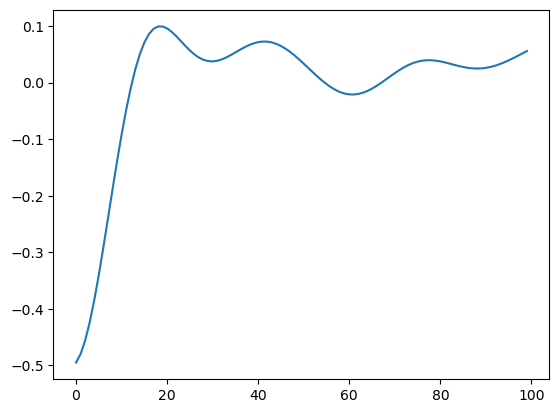

In [43]:
L = 12
H = op.heisenberg_operator(L).to_mpo(pauli=False)
𝜓t = qtc.MPS.from_product_state(["up","down"]*(L//2))
psis = H.tdvp(init=𝜓t, time_step=-0.1j, final_time=-10.j, outputlevel=0)
Ss = []
for t, phi in tqdm(psis, ascii=True, total=100):
    Ss.append(phi.measure('z', 3).item().real)
import matplotlib.pyplot as plt
plt.plot(Ss)